In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import utils
from external.api_repo.generators import single_well_generator

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [24]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [59]:
boltzman= 1.38e-23
zeta = 9.24e-6

T = 300
D = (T*boltzman)/zeta
t0=0
total_time = 5
time_step = 4e-3
k=0.9e-6
x0_mean=0
x_mu=3

print(D)


4.480519480519481e-16


In [60]:
x,times = single_well_generator(
    T=T,
    total_time=total_time,
    time_step=time_step,    
    x0_mean=x0_mean,
    zeta=zeta,
    k=k,
    x_mu=x_mu,
    boltzmann=boltzman,
    device=device,
)


series = pd.Series(x[0].detach().cpu().numpy())

ADF Statistic: -15.833186858177443
p-value: 9.888227032743198e-29


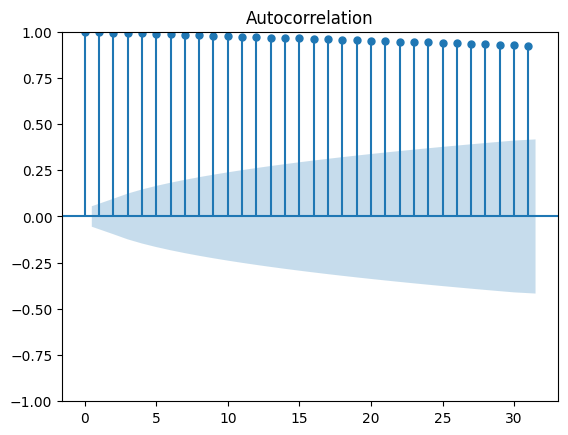

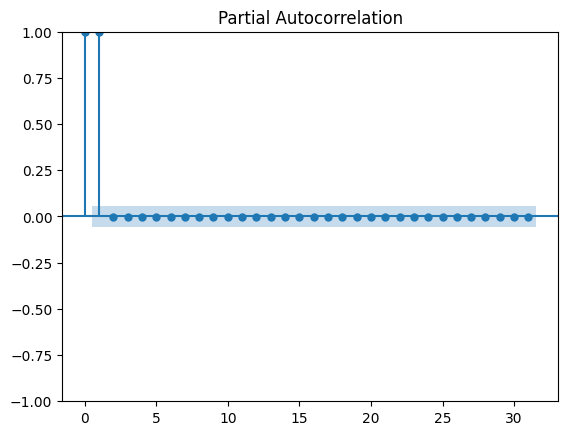

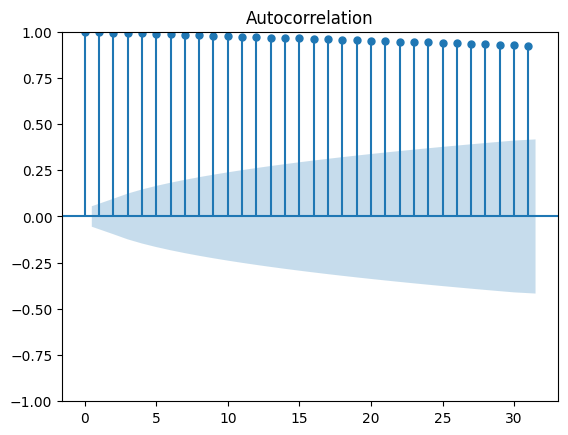

In [61]:
#test for stationarity
ADF_p = adfuller(series)
print('ADF Statistic:', ADF_p[0])
print('p-value:', ADF_p[1])

plot_pacf(series)
plot_acf(series)

In [62]:
print(total_time/time_step)

1250.0


In [63]:
t=750
train = series.iloc[:t+1]
model = ARIMA(train, order=(30, 0, 1))
result = model.fit()

/home/mea/nf/venv/lib/python3.12/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/home/mea/nf/venv/lib/python3.12/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


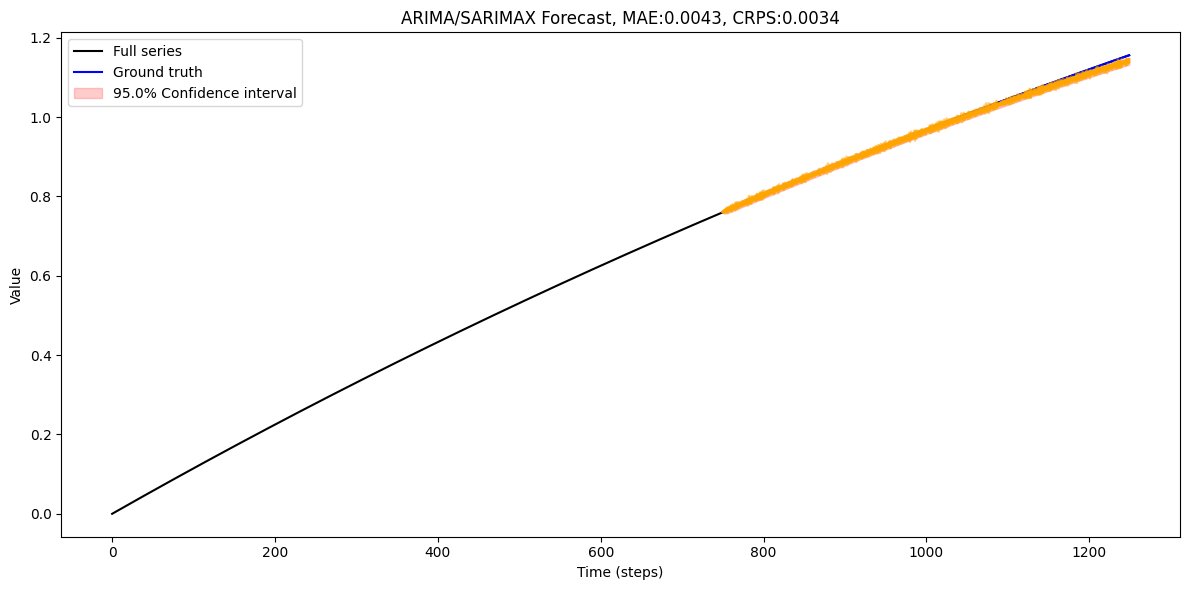

In [64]:
utils.plot_arima_simulated_forecast(series, result,t=t,n_sim=10)